In [1]:
import pandas as pd

train = pd.read_csv("/content/customer_churn_dataset-training-master.csv")
test = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")

print("Training data:", train.shape)
print("Testing data:", test.shape)

train.head()

Training data: (440833, 12)
Testing data: (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [2]:
print("Training Dataset Information")
print("=" * 40)

print("\nColumns:")
print(train.columns.tolist())

print("\nMissing Values:")
print(train.isnull().sum())

print("\nChurn Distribution:")
print(train["Churn"].value_counts())

Training Dataset Information

Columns:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Missing Values:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Churn Distribution:
Churn
1.0    249999
0.0    190833
Name: count, dtype: int64


In [3]:
train_clean = train.dropna().copy()
test_clean = test.dropna().copy()

print("Original training rows:", len(train))
print("Clean training rows:", len(train_clean))

print("\nMissing values after cleaning:")
print(train_clean.isnull().sum().sum())

Original training rows: 440833
Clean training rows: 440832

Missing values after cleaning:
0


In [4]:
churn_rate = train_clean["Churn"].mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")
print(f"Non-Churn Rate: {100 - churn_rate:.2f}%")

Overall Churn Rate: 56.71%
Non-Churn Rate: 43.29%


In [5]:
subscription_churn = (
    train_clean.groupby("Subscription Type")["Churn"]
    .mean() * 100
)

print("Churn Rate by Subscription Type:")
print(subscription_churn.round(2))

Churn Rate by Subscription Type:
Subscription Type
Basic       58.18
Premium     55.94
Standard    56.07
Name: Churn, dtype: float64


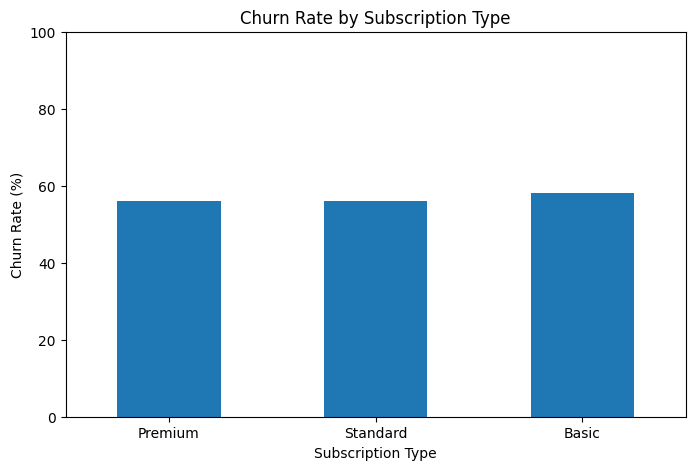

In [6]:
import matplotlib.pyplot as plt

subscription_churn.sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

In [7]:
support_churn = (
    train_clean.groupby("Support Calls")["Churn"]
    .mean() * 100
)

print("Churn Rate by Support Calls:")
print(support_churn.round(2))

Churn Rate by Support Calls:
Support Calls
0.0      30.28
1.0      30.36
2.0      31.55
3.0      41.64
4.0      58.50
5.0      94.71
6.0     100.00
7.0     100.00
8.0     100.00
9.0     100.00
10.0    100.00
Name: Churn, dtype: float64


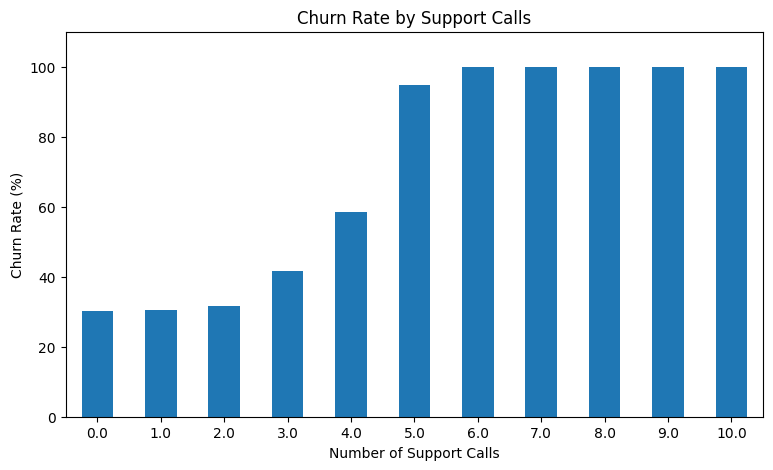

In [8]:
support_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Support Calls")
plt.xlabel("Number of Support Calls")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 110)
plt.xticks(rotation=0)
plt.show()

In [9]:
tenure_churn = (
    train_clean.groupby("Tenure")["Churn"]
    .mean() * 100
)

print("Churn Rate by Tenure:")
print(tenure_churn.round(2))


Churn Rate by Tenure:
Tenure
1.0     65.37
2.0     64.71
3.0     63.44
4.0     64.14
5.0     64.51
6.0     53.53
7.0     54.58
8.0     55.33
9.0     53.80
10.0    53.75
11.0    54.18
12.0    62.02
13.0    62.86
14.0    63.82
15.0    63.01
16.0    62.81
17.0    63.67
18.0    64.49
19.0    63.40
20.0    62.59
21.0    63.17
22.0    63.79
23.0    62.44
24.0    63.18
25.0    53.01
26.0    54.28
27.0    54.21
28.0    54.24
29.0    54.33
30.0    55.38
31.0    53.50
32.0    54.71
33.0    53.73
34.0    54.30
35.0    54.58
36.0    53.17
37.0    54.03
38.0    54.56
39.0    54.33
40.0    53.76
41.0    54.16
42.0    54.55
43.0    54.13
44.0    53.30
45.0    53.92
46.0    54.39
47.0    54.27
48.0    54.12
49.0    53.46
50.0    53.68
51.0    55.02
52.0    54.09
53.0    54.05
54.0    54.72
55.0    55.34
56.0    54.10
57.0    54.53
58.0    54.49
59.0    55.02
60.0    53.08
Name: Churn, dtype: float64


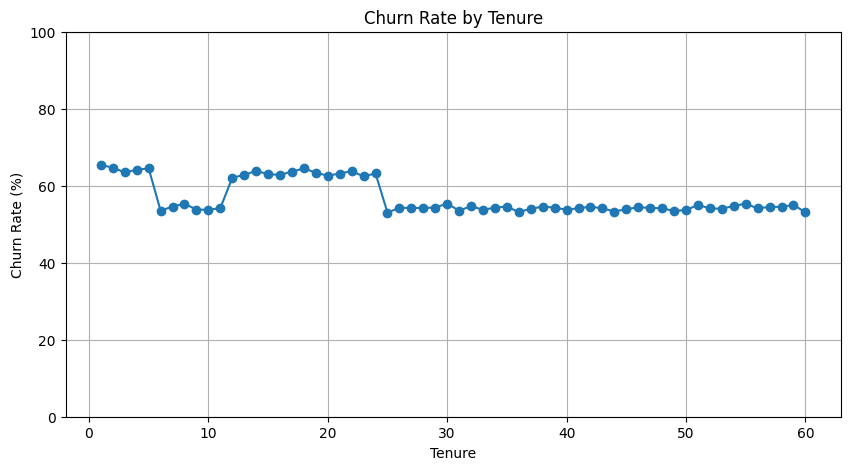

In [10]:
tenure_churn.plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.grid(True)
plt.show()

In [11]:
payment_delay_churn = (
    train_clean.groupby("Payment Delay")["Churn"]
    .mean() * 100
)

print("Churn Rate by Payment Delay:")
print(payment_delay_churn.round(2))

Churn Rate by Payment Delay:
Payment Delay
0.0      46.67
1.0      45.78
2.0      46.68
3.0      46.58
4.0      46.36
5.0      46.62
6.0      46.69
7.0      46.33
8.0      47.12
9.0      46.66
10.0     46.15
11.0     46.93
12.0     46.17
13.0     46.38
14.0     46.48
15.0     46.95
16.0     46.97
17.0     46.52
18.0     46.17
19.0     46.09
20.0     46.56
21.0    100.00
22.0    100.00
23.0    100.00
24.0    100.00
25.0    100.00
26.0    100.00
27.0    100.00
28.0    100.00
29.0    100.00
30.0    100.00
Name: Churn, dtype: float64


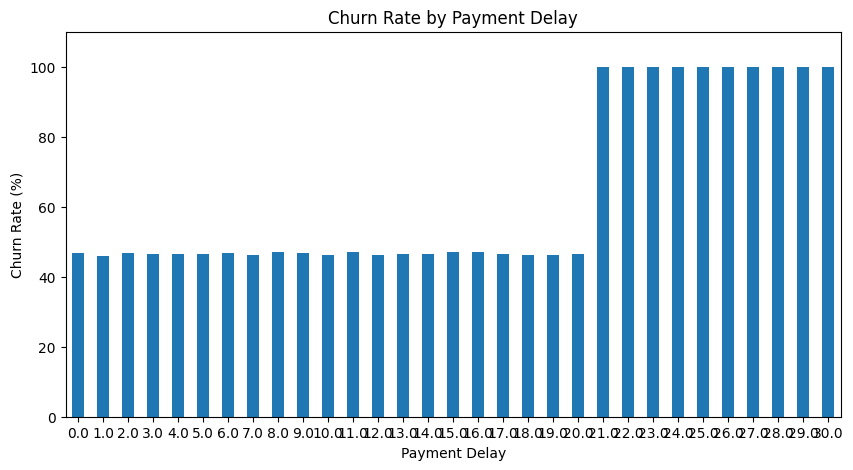

In [12]:
payment_delay_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Delay")
plt.xlabel("Payment Delay")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 110)
plt.xticks(rotation=0)
plt.show()

In [13]:
contract_churn = (
    train_clean.groupby("Contract Length")["Churn"]
    .mean() * 100
)

print("Churn Rate by Contract Length:")
print(contract_churn.round(2))

Churn Rate by Contract Length:
Contract Length
Annual        46.08
Monthly      100.00
Quarterly     46.03
Name: Churn, dtype: float64


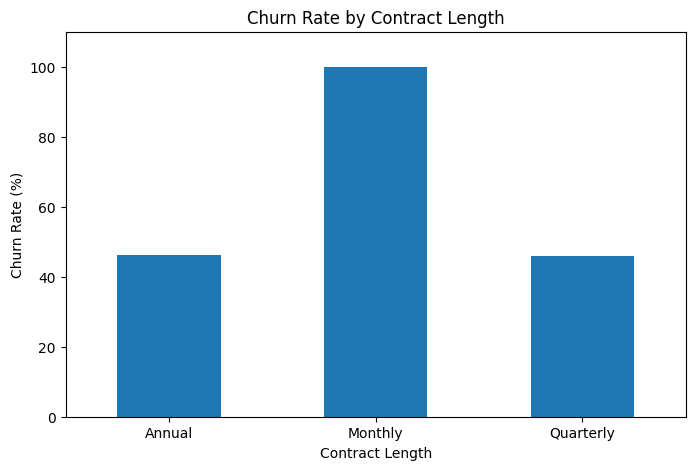

In [14]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Length")
plt.xlabel("Contract Length")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 110)
plt.xticks(rotation=0)
plt.show()


In [15]:
summary = pd.DataFrame({
    "Analysis": [
        "Overall Churn Rate",
        "Basic Subscription Churn",
        "Premium Subscription Churn",
        "Standard Subscription Churn",
        "Annual Contract Churn",
        "Monthly Contract Churn",
        "Quarterly Contract Churn"
    ],
    "Churn Rate (%)": [
        56.71,
        58.18,
        55.94,
        56.07,
        46.08,
        100.00,
        46.03
    ]
})

summary


,Analysis,Churn Rate (%)
0,Overall Churn Rate,56.71
1,Basic Subscription Churn,58.18
2,Premium Subscription Churn,55.94
3,Standard Subscription Churn,56.07
4,Annual Contract Churn,46.08
5,Monthly Contract Churn,100.00
6,Quarterly Contract Churn,46.03


## Key Findings

- The overall churn rate in the cleaned training dataset is 56.71%.
- Churn rates vary across subscription types, with Basic at 58.18%, Premium at 55.94%, and Standard at 56.07%.
- Higher churn rates were observed among customers with more support calls. In this dataset, customers with 5 support calls had a churn rate of 94.71%.
- Payment delay values from 21 to 30 days show a 100% churn rate in the dataset.
- Contract length shows a clear difference in observed churn rates, with Monthly contracts showing 100% churn in this dataset.
- Tenure also shows variation in churn rates across different customer tenure periods.